In [ ]:
from selenium import webdriver
from bs4 import BeautifulSoup
import pandas as pd
import time

driver = webdriver.Chrome()
driver.get("https://www.edutopia.org/search?query=student%20screen%20time")

time.sleep(5)  # wait for full load

html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

articles = soup.find_all("a")

data = []

for a in articles:
    title = a.text.strip()
    link = a.get("href")

    if title and link:
        if "student" in title.lower():
            if link.startswith("/"):
                link = "https://www.edutopia.org" + link

            data.append([title, link])

print("Found:", len(data))

df = pd.DataFrame(data, columns=["Title", "Link"])
df.to_csv("result.csv", index=False)

print("✅ Selenium scraping successful!")

driver.quit()


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# your scraped CSV
df = pd.read_csv("result.csv")

data = []

headers = {"User-Agent": "Mozilla/5.0"}

for index, row in df.iterrows():
    url = row["Link"]
    
    try:
        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, "html.parser")

        paragraphs = soup.find_all("p")
        content = " ".join([p.text for p in paragraphs[:5]])  # first 5 paras

        data.append([row["Title"], url, content])

        time.sleep(2)  # avoid blocking

    except:
        print("Error in:", url)

new_df = pd.DataFrame(data, columns=["Title", "Link", "Content"])
new_df.to_csv("final_data.csv", index=False)

print("✅ Content extracted!")


✅ Content extracted!


In [3]:
import pandas as pd

df = pd.read_csv("final_data.csv")

insights = []

for text in df["Content"]:
    text = text.lower()

    if "hour" in text:
        insights.append("High screen time observed")
    elif "depression" in text or "poor performance" in text:
        insights.append("Negative impact on productivity")
    elif "motivation" in text:
        insights.append("Affects motivation")
    elif "focus" in text or "distraction" in text:
        insights.append("Causes distraction")
    else:
        insights.append("General impact")

df["Insight"] = insights

df.to_csv("final_with_insights.csv", index=False)

print("✅ Insights added!")


✅ Insights added!


<Axes: xlabel='Insight'>

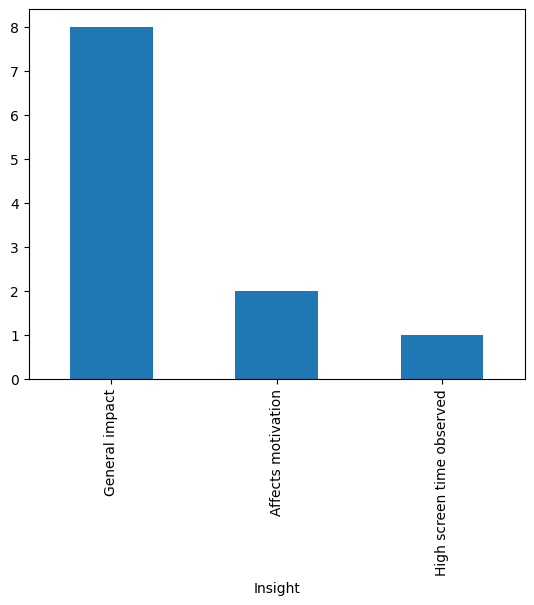

In [4]:
df["Insight"].value_counts().plot(kind="bar")
